# import libraries


In [41]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

from sklearn.datasets import load_digits
from sklearn.metrics import f1_score

## device

In [42]:
device = "cuda" if torch.cuda.is_available()==True else "cpu"
device

'cuda'

## read data

In [43]:
data = load_digits()
y = data.target
img = data.images
X = data.data

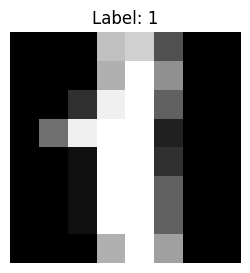

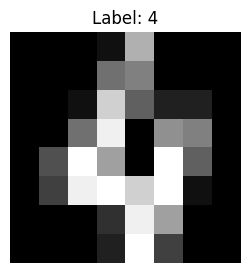

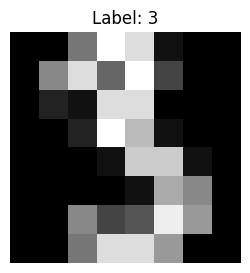

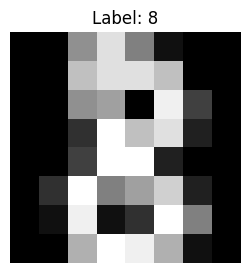

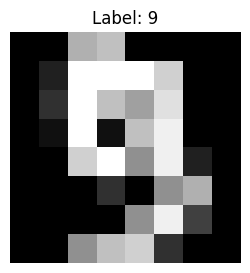

In [44]:
for i in [1, 4, 3, 8, 9]:
    plt.figure(figsize=(3,3))
    plt.imshow(img[i], cmap="gray")
    plt.title(f"Label: {y[i].item()}")
    plt.axis("off")
    plt.show()

In [45]:
X = torch.from_numpy(X).float().to(device)
y = torch.from_numpy(y).long().to(device)

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=47, test_size=0.2)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([1437, 64]) torch.Size([1437])
torch.Size([360, 64]) torch.Size([360])


# model

In [47]:
# main model:
class DigitModel(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.network = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 16),
            nn.ReLU(),
            nn.Linear(16, 10)
            )
        
    def forward(self, x):
        return self.network(x)

In [48]:
model = DigitModel().to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.005)
model.state_dict()

OrderedDict([('network.0.weight',
              tensor([[-0.1117, -0.1125, -0.0081,  ...,  0.0769, -0.0936, -0.0475],
                      [ 0.0535,  0.0826, -0.0618,  ...,  0.0598, -0.0974,  0.0598],
                      [-0.0418, -0.1061,  0.0355,  ...,  0.0018, -0.1118, -0.0689],
                      ...,
                      [ 0.0022,  0.1113, -0.1206,  ..., -0.0769,  0.0317,  0.0378],
                      [-0.1198, -0.0618, -0.1071,  ...,  0.0642, -0.0297, -0.1214],
                      [-0.0071,  0.0536, -0.0104,  ...,  0.0971,  0.0021, -0.0633]],
                     device='cuda:0')),
             ('network.0.bias',
              tensor([-0.0842,  0.0417, -0.1200,  0.0577, -0.0922, -0.0838,  0.0271,  0.1049,
                      -0.0558,  0.0894,  0.0293, -0.0336,  0.0590,  0.0530,  0.0991, -0.0973,
                       0.0952, -0.0476,  0.1010,  0.0807, -0.0567, -0.0956, -0.0110,  0.1203,
                       0.0180,  0.1038, -0.0132,  0.1025,  0.0325,  0.0055,  0.0

In [49]:
print(y_train.dtype)
print(y_train.min(), y_train.max())

torch.int64
tensor(0, device='cuda:0') tensor(9, device='cuda:0')


In [50]:
# main loop:

torch.manual_seed(47)

epochs = 900

train_loss_values = []
test_loss_values = []
train_r2_values = []
test_r2_values = []
epoch_count = []

for epoch in range(epochs):
    # train:
    model.train()
    y_logits = model(X_train)
    y_pred = torch.argmax(y_logits, dim=1)
    loss = loss_fn(y_logits, y_train)
    # backward:
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # Calculate R² for training (regression metric)
    with torch.no_grad():
        train_f1 = f1_score(y_train.cpu().numpy(), y_pred.cpu().numpy(), average="weighted")
        
    # test evaluation:
    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test)
        test_pred = torch.argmax(test_logits, dim=1)
        test_loss = loss_fn(test_logits, y_test)
        test_f1 = f1_score(y_test.cpu().numpy(), test_pred.cpu().numpy(), average="weighted")
    
    # Store values
    epoch_count.append(epoch)
    train_loss_values.append(loss.item())
    test_loss_values.append(test_loss.item())
    train_r2_values.append(train_f1)
    test_r2_values.append(test_f1)
    
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Train Loss: {loss.item():.4f} | Test Loss: {test_loss.item():.4f} | Train f1: {train_f1:.4f} | Test f1: {test_f1:.4f}")


Epoch: 0 | Train Loss: 2.3549 | Test Loss: 2.2504 | Train f1: 0.0422 | Test f1: 0.0172
Epoch: 10 | Train Loss: 1.0488 | Test Loss: 0.9310 | Train f1: 0.6208 | Test f1: 0.6842
Epoch: 20 | Train Loss: 0.1984 | Test Loss: 0.1866 | Train f1: 0.9347 | Test f1: 0.9388
Epoch: 30 | Train Loss: 0.0697 | Test Loss: 0.1064 | Train f1: 0.9812 | Test f1: 0.9664
Epoch: 40 | Train Loss: 0.0217 | Test Loss: 0.0974 | Train f1: 0.9972 | Test f1: 0.9666
Epoch: 50 | Train Loss: 0.0077 | Test Loss: 0.0830 | Train f1: 1.0000 | Test f1: 0.9722
Epoch: 60 | Train Loss: 0.0034 | Test Loss: 0.0887 | Train f1: 1.0000 | Test f1: 0.9722
Epoch: 70 | Train Loss: 0.0019 | Test Loss: 0.0905 | Train f1: 1.0000 | Test f1: 0.9722
Epoch: 80 | Train Loss: 0.0013 | Test Loss: 0.0912 | Train f1: 1.0000 | Test f1: 0.9722
Epoch: 90 | Train Loss: 0.0010 | Test Loss: 0.0919 | Train f1: 1.0000 | Test f1: 0.9722
Epoch: 100 | Train Loss: 0.0008 | Test Loss: 0.0927 | Train f1: 1.0000 | Test f1: 0.9722
Epoch: 110 | Train Loss: 0.0007 

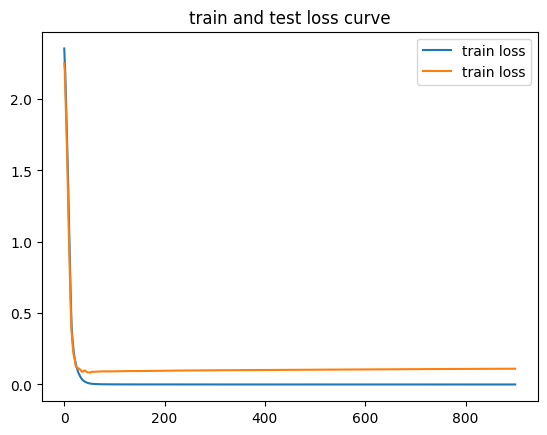

In [51]:
plt.title("train and test loss curve")
plt.plot(epoch_count, train_loss_values, label="train loss")
plt.plot(epoch_count, test_loss_values, label="train loss")
plt.legend()

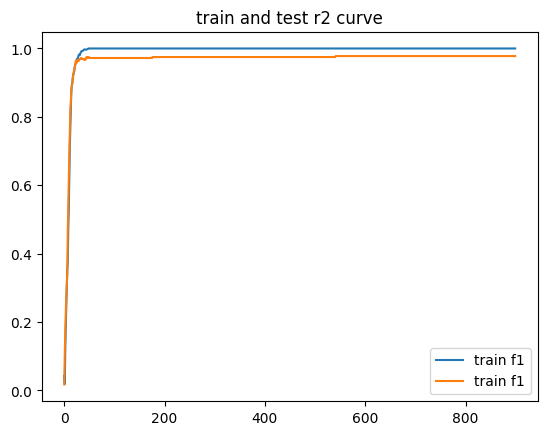

In [52]:
plt.title("train and test r2 curve")
plt.plot(epoch_count, train_r2_values, label="train f1")
plt.plot(epoch_count, test_r2_values, label="train f1")
plt.legend()